📤 Step 1 — Uploading Dataset ZIP


In [ ]:
from google.colab import files
uploaded = files.upload()



Saving Plant_1_Generation_Data.csv.zip to Plant_1_Generation_Data.csv.zip


📁 Step 2 — Checking Uploaded Files


In [ ]:
import os
os.listdir()

['.config', 'Plant_1_Generation_Data.csv.zip', 'sample_data']

🗜 Step 3 — Extracting ZIP File


In [ ]:
import zipfile
with zipfile.ZipFile("Plant_1_Generation_Data.csv.zip", 'r') as zip_ref:
    zip_ref.extractall()


📊 Step 4 — Loading Dataset into Pandas


In [ ]:

import pandas as pd
df = pd.read_csv("Plant_1_Generation_Data.csv")
df.head()

,DATE_TIME,PLANT_ID,SOURCE_KEY,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
0,15-05-2020 00:00,4135001,1BY6WEcLGh8j5v7,0.0,0.0,0.0,6259559.0
1,15-05-2020 00:00,4135001,1IF53ai7Xc0U56Y,0.0,0.0,0.0,6183645.0
2,15-05-2020 00:00,4135001,3PZuoBAID5Wc2HD,0.0,0.0,0.0,6987759.0
3,15-05-2020 00:00,4135001,7JYdWkrLSPkdwr4,0.0,0.0,0.0,7602960.0
4,15-05-2020 00:00,4135001,McdE0feGgRqW7Ca,0.0,0.0,0.0,7158964.0


In [ ]:
import pandas as pd


df['DATE_TIME'] = pd.to_datetime(df['DATE_TIME'], format='%d-%m-%Y %H:%M')

df['HOUR'] = df['DATE_TIME'].dt.hour

X = df[['DC_POWER', 'DAILY_YIELD', 'HOUR']]
y = df['AC_POWER']

print("Data ready ✅")
df.head()

Data ready ✅


,DATE_TIME,PLANT_ID,SOURCE_KEY,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,HOUR
0,2020-05-15,4135001,1BY6WEcLGh8j5v7,0.0,0.0,0.0,6259559.0,0
1,2020-05-15,4135001,1IF53ai7Xc0U56Y,0.0,0.0,0.0,6183645.0,0
2,2020-05-15,4135001,3PZuoBAID5Wc2HD,0.0,0.0,0.0,6987759.0,0
3,2020-05-15,4135001,7JYdWkrLSPkdwr4,0.0,0.0,0.0,7602960.0,0
4,2020-05-15,4135001,McdE0feGgRqW7Ca,0.0,0.0,0.0,7158964.0,0


✂ Step 5 — Splitting Data

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 55022
Testing samples: 13756


🤖 Step 6 — Training Linear Regression



In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

print("Model training complete ✅")


Model training complete ✅


🔮 Step 7 — Making Sample Predictions



In [ ]:
y_pred = model.predict(X_test)

print("Sample predictions:", y_pred[:5])

Sample predictions: [2.60046975e-01 2.49966040e-01 7.16805229e+02 2.80063044e-01
 7.49271776e+02]


📈 Step 8 — Plotting Actual vs Predicted



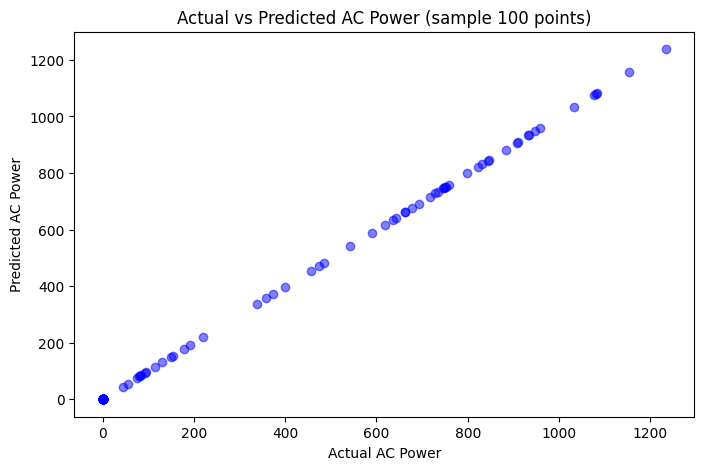

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.scatter(y_test[:100], y_pred[:100], color='blue', alpha=0.5)
plt.xlabel("Actual AC Power")
plt.ylabel("Predicted AC Power")
plt.title("Actual vs Predicted AC Power (sample 100 points)")
plt.show()


📉 Step 9 — Evaluating Linear Regression


In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("✅ Model Accuracy (R² Score):", round(r2, 3))
print("📉 Mean Absolute Error:", round(mae, 3))


✅ Model Accuracy (R² Score): 1.0
📉 Mean Absolute Error: 0.715



🌲 Step 10 — Training Random Forest Model


In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print("Random Forest R²:", round(r2_score(y_test, rf_pred), 3))
print("MAE:", round(mean_absolute_error(y_test, rf_pred), 3))


Random Forest R²: 1.0
MAE: 0.145


🧹 Step 11 — Cleaning Timestamp & Reloading Data


In [ ]:
import pandas as pd

df = pd.read_csv("Plant_1_Generation_Data.csv")
df['DATE_TIME'] = pd.to_datetime(df['DATE_TIME'], format='%d-%m-%Y %H:%M')
df.head()

,DATE_TIME,PLANT_ID,SOURCE_KEY,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
0,2020-05-15,4135001,1BY6WEcLGh8j5v7,0.0,0.0,0.0,6259559.0
1,2020-05-15,4135001,1IF53ai7Xc0U56Y,0.0,0.0,0.0,6183645.0
2,2020-05-15,4135001,3PZuoBAID5Wc2HD,0.0,0.0,0.0,6987759.0
3,2020-05-15,4135001,7JYdWkrLSPkdwr4,0.0,0.0,0.0,7602960.0
4,2020-05-15,4135001,McdE0feGgRqW7Ca,0.0,0.0,0.0,7158964.0


🧪 Step 12 — Creating Feature Engineering Columns


In [ ]:
df['HOUR'] = df['DATE_TIME'].dt.hour
df['WEEKDAY'] = df['DATE_TIME'].dt.weekday
df['ROLLING_DC_4'] = df['DC_POWER'].rolling(window=4, min_periods=1).mean()
df['EFFICIENCY'] = (df['AC_POWER'] / (df['DC_POWER'] + 1e-6)).replace([float('inf'), -float('inf')], 0)
df.head()

,DATE_TIME,PLANT_ID,SOURCE_KEY,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,HOUR,WEEKDAY,ROLLING_DC_4,EFFICIENCY
0,2020-05-15,4135001,1BY6WEcLGh8j5v7,0.0,0.0,0.0,6259559.0,0,4,0.0,0.0
1,2020-05-15,4135001,1IF53ai7Xc0U56Y,0.0,0.0,0.0,6183645.0,0,4,0.0,0.0
2,2020-05-15,4135001,3PZuoBAID5Wc2HD,0.0,0.0,0.0,6987759.0,0,4,0.0,0.0
3,2020-05-15,4135001,7JYdWkrLSPkdwr4,0.0,0.0,0.0,7602960.0,0,4,0.0,0.0
4,2020-05-15,4135001,McdE0feGgRqW7Ca,0.0,0.0,0.0,7158964.0,0,4,0.0,0.0


📊 Step 13 — Visualizing AC Power Distribution



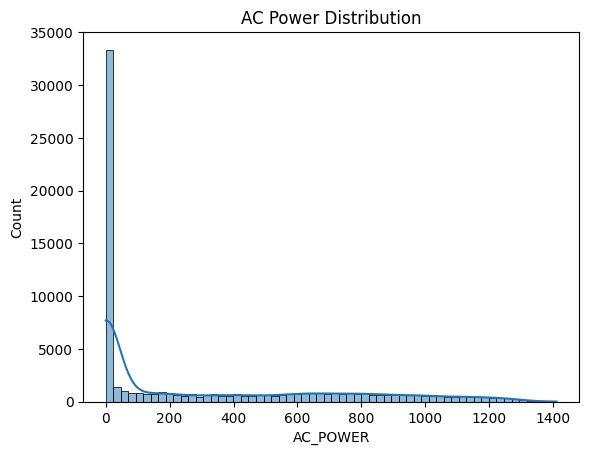

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['AC_POWER'], bins=60, kde=True)
plt.title("AC Power Distribution")
plt.show()

🕒 Step 14 — Plotting Average AC Power by Hour


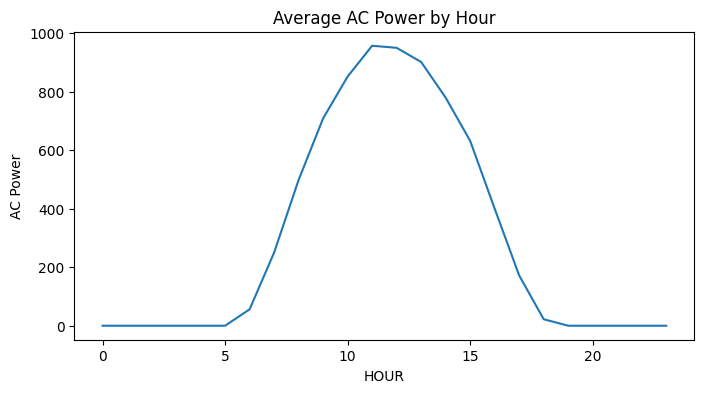

In [ ]:
df.groupby('HOUR')['AC_POWER'].mean().plot(figsize=(8,4))
plt.title("Average AC Power by Hour")
plt.ylabel("AC Power")
plt.show()

🔥 Step 15 — Correlation Heatmap


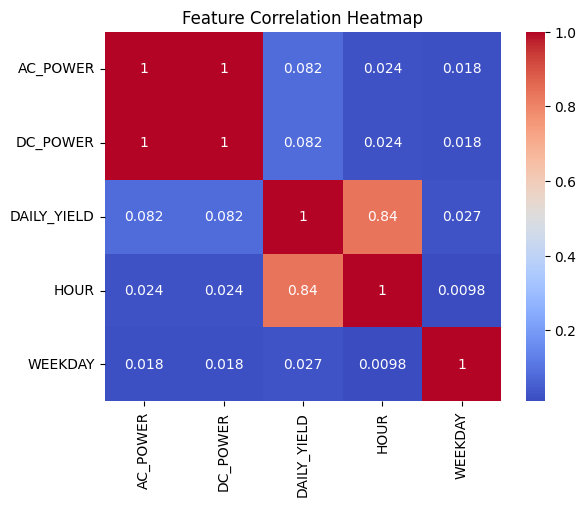

In [ ]:


sns.heatmap(df[['AC_POWER','DC_POWER','DAILY_YIELD','HOUR','WEEKDAY']].corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

⚡ Step 16 — Installing XGBoost


In [ ]:

!pip install xgboost

🤖 Step 17 — Training XGBoost Model



In [ ]:
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

X = df[['DC_POWER','DAILY_YIELD','HOUR','WEEKDAY','ROLLING_DC_4','EFFICIENCY']]
y = df['AC_POWER']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=6)
model.fit(X_train, y_train)

pred = model.predict(X_test)

print("R2 Score:", r2_score(y_test, pred))
print("MAE:", mean_absolute_error(y_test, pred))

R2 Score: 0.9999797011821723
MAE: 0.735711080938969


💾 Step 18 — Saving XGBoost Model


In [ ]:
import joblib
joblib.dump(model, "week3_xgb_model.pkl")

['week3_xgb_model.pkl']

🧠 Step 19 — Creating Custom Prediction Function


In [ ]:
import pandas as pd
import numpy as np

def predict_ac_power(dc_power, daily_yield, date_time, last_dc_values=None):
    dt = pd.to_datetime(date_time)
    hour = dt.hour
    weekday = dt.weekday()

    if last_dc_values is None or len(last_dc_values) < 4:
        rolling_dc = dc_power
    else:
        rolling_dc = np.mean(last_dc_values[-4:])

    if dc_power <= 0:
        efficiency = 0
    else:
        efficiency = 0.85

    features = [[dc_power, daily_yield, hour, weekday, rolling_dc, efficiency]]
    pred = model.predict(features)
    return pred[0]

🔮 Step 20 — Testing Prediction on Sample Rows


In [ ]:
sample = X_test.iloc[0:5]
pred = model.predict(sample)

print("Predicted AC Power:", pred)
print("Actual AC Power:", y_test.iloc[0:5].values)

Predicted AC Power: [1.4059961e-02 1.4059961e-02 7.1822125e+02 1.4059961e-02 7.4910889e+02]
Actual AC Power: [  0.       0.     718.0625   0.     750.4375]


🔧 Step 21 — Checking Feature Columns


In [ ]:
print(X.columns)

Index(['DC_POWER', 'DAILY_YIELD', 'HOUR', 'WEEKDAY', 'ROLLING_DC_4',
       'EFFICIENCY'],
      dtype='object')


⚡ Step 22 — Manual Input Prediction


In [ ]:
dc = 450
daily = 15000
hour = 13
weekday = 2
rolling_dc = 420
efficiency = 0.85

predicted_power = model.predict([[dc, daily, hour, weekday, rolling_dc, efficiency]])
print(predicted_power)

[44.710747]


🔮 Step 23 — Using the Custom Function



In [ ]:
predict_ac_power(450, 15000, "2020-05-20 13:00:00")

np.float32(44.710747)

Step 24- Final Performance Comparison


In [28]:
from sklearn.metrics import r2_score, mean_absolute_error

print("Final Model Performance Comparison\n")

rf_r2 = r2_score(y_test, rf_pred)
rf_mae = mean_absolute_error(y_test, rf_pred)

print("Random Forest Regressor:")
print(f"R² Score: {rf_r2:.4f}")
print(f"MAE: {rf_mae:.4f}\n")

xgb_pred = model.predict(X_test)
xgb_r2 = r2_score(y_test, xgb_pred)
xgb_mae = mean_absolute_error(y_test, xgb_pred)

print("XGBoost Regressor:")
print(f"R² Score: {xgb_r2:.4f}")
print(f"MAE: {xgb_mae:.4f}")

Final Model Performance Comparison

Random Forest Regressor:
R² Score: 1.0000
MAE: 0.1453

XGBoost Regressor:
R² Score: 1.0000
MAE: 0.7357
